# Анализ рынка недвижимости

Заказчик — агентство недвижимости из Петрозаводска, которое планирует выйти на рынок Санкт-Петербурга и Ленинградской области и перевести основной офис в новый регион.

Необходимо помочь заказчику спланировать бизнес-стратегию, выбрать сегмент недвижимости с высоким спросом и подходящий сезон для публикации объявлений, а также доработать дашборд по техническому заданию от заказчиков.

Нам предстоит работать с архивной информацией сервиса Яндекс Недвижимость: объявления о продаже жилой недвижимости в Санкт-Петербурге и Ленинградской области за несколько лет.

## Что нужно сделать
Задачи: познакомиться с данными, решить две аналитические ad hoc задачи с помощью SQL-запросов и сформулировать выводы, доработать дашборд заказчика в DataLens и дополнить его новыми элементами.

## Описание данных

Таблица `advertisement` содержит информацию об объявлениях:

-    `id` — идентификатор объявления (первичный ключ);
-    `first_day_exposition` — дата подачи объявления;
-    `days_exposition` — длительность нахождения объявления на сайте (в днях);
-    `last_price` — стоимость квартиры в объявлении, в руб.

Таблица `flats` содержит информацию о квартирах:

-    `id` — идентификатор квартиры (первичный ключ, связан с первичным ключом id таблицы advertisement);
-    `city_id` — идентификатор города (внешний ключ, связан с city_id таблицы city);
-    `type_id` — идентификатор типа населённого пункта (внешний ключ, связан с type_id таблицы type);
-    `total_area` — общая площадь квартиры, в кв. метрах;
-    `rooms` — число комнат;
-    `ceiling_height` — высота потолка, в метрах;
-    `floors_total` — этажность дома, в котором находится квартира;
-    `living_area` — жилая площадь, в кв. метрах;
-    `floor` — этаж квартиры;
-    `is_apartment` — указатель, является ли квартира апартаментами (1 — является, 0 — не является);
-    `open_plan` — указатель, имеется ли в квартире открытая планировка (1 — открытая планировка квартиры, 0 — открытая планировка отсутствует);
-    `kitchen_area` — площадь кухни, в кв. метрах;
-    `balcony` — количество балконов в квартире;
-    `airports_nearest` — расстояние до ближайшего аэропорта, в метрах;
-    `parks_around3000` — число парков в радиусе трёх километров;
-    `ponds_around3000` — число водоёмов в радиусе трёх километров;

Таблица `city` содержит информацию о городах:

-    `city_id` — идентификатор населённого пункта (первичный ключ);
-    `city` — название населённого пункта.

Таблица `type` содержит информацию о городах:

-    `type_id` — идентификатор типа населённого пункта (первичный ключ);
-    `type` — название типа населённого пункта.

## 1. Знакомство и исследование данных

### 1.1. Временной интервал

Определим, за какой период представлены данные о продаже недвижимости по дате публикации объявления.

In [ ]:
SELECT MIN(first_day_exposition), MAX(first_day_exposition)
FROM advertisement

min       |max       |
:----------:|:----------:|
2014-11-27|2019-05-03|

Данные за 2014 и 2019 годы — неполные: за 2014 год данные начинаются с конца ноября, а за 2019 — заканчиваются в мае

### 1.2. Типы населённых пунктов

Изучим распределение объявлений по населённым пунктам в зависимости от их типа и подсчитаем для каждого типа количество объявлений и количество населённых пунктов.

In [ ]:
SELECT type,
    COUNT(id),
    COUNT(distinct city_id) AS city_count
FROM flats
JOIN type ON type.type_id = flats.type_id
GROUP BY type
ORDER BY COUNT(id) DESC

type                                     |count|city_count|
:----------------------------------------|:---:|:--------:|
город                                    |20008|        43|
посёлок                                  | 2092|       113|
деревня                                  |  945|       106|
посёлок городского типа                  |  363|        30|
городской посёлок                        |  187|        13|
село                                     |   32|         9|
посёлок при железнодорожной станции      |   15|         6|
садовое товарищество                     |    4|         4|
коттеджный посёлок                       |    3|         3|
садоводческое некоммерческое товарищество|    1|         1|

Данные содержат информацию о 10 типах населённых пунктов.  
Города лидируют по количеству объявлений: около 85% объявлений приходится на этот тип населённого пункта. Затем идет посёлок — около 9%. Остальные типы населённых пунктов содержат не такое большое количество объявлений в процентном соотношении.

### 1.3. Время активности объявления

Данные содержат не только время публикации объявления, но и количество дней, в течение которых объявление было активным, то есть доступным для потенциальных покупателей. Если объявления снимали с продажи, в большинстве случаев можно решить, что недвижимость продали. В рамках этого проекта будем считать именно так, поскольку других прямых данных о продажах нет.  
Подсчитаем основные статистики по полю со временем активности объявлений: минимальное, максимальное, среднее значения и медиана.

In [ ]:
SELECT MIN(days_exposition),
    MAX(days_exposition),
    ROUND(AVG(days_exposition)::numeric, 2) AS avg,
    PERCENTILE_DISC(0.5) WITHIN GROUP (ORDER BY days_exposition) AS median
FROM advertisement

min|max   |avg   |median|
:---:|:---:|:---:|:---:|
1.0|1580.0|180.75|  95.0|

Максимальная длительность публикации объявления — более 4 лет!  

Медиана отличается от среднего значения, что может говорить о наличии единичных высоких значений — выбросов.  
Результаты показывают, что половину объявлений сняли с публикации в течение 95 дней с момента публикации.

### 1.4. Доля снятых с публикации объявлений

Рассчитаем процент объявлений, которые сняли с публикации.

In [ ]:
SELECT 100 - ROUND(COUNT(id) FILTER(WHERE days_exposition IS NULL)::numeric * 100/ COUNT(*), 2)
FROM advertisement

Процент объявлений, которые сняли с публикации, составляет 86.55. Если считать, что эти объекты проданы, то получается хорошая выборка данных для анализа.

### 1.5. Объявления Санкт-Петербурга

Архив объявлений содержит объявления о продаже недвижимости в Санкт-Петербурге и Ленинградской области. Поскольку это два разных субъекта, стоит оценить соотношение объявлений между ними. Это поможет понять, стоит ли изучать такие рынки раздельно.  
Подсчитаем, какой процент объявлений о продаже квартир в Санкт-Петербурге.

In [ ]:
SELECT ROUND(COUNT(id) FILTER (WHERE city = 'Санкт-Петербург')::numeric * 100/ COUNT(*), 2)
FROM flats
JOIN city USING (city_id)

66.47 % всех продаваемых объектов недвижимости находятся в пределах Санкт-Петербурга, что в целом ожидаемо.  
Соотношение между объявлениями в Санкт-Петербурге и Ленинградской области — примерно 66 к 34 или около 2 к 1. Такое соотношение позволяет изучить объявления в двух субъектах раздельно и сопоставить результаты между собой, хоть и объявлений в Санкт-Петербурге почти в два раза больше.

### 1.6. Стоимость квадратного метра

Подсчитаем основные статистические показатели для значений стоимости одного квадратного метра: минимальное, максимальное, среднее значения и медиану. 

In [ ]:
SELECT ROUND(MIN(last_price/total_area)::numeric, 2) AS min_price,
    ROUND(MAX(last_price/total_area)::numeric, 2) AS max_price,
    ROUND(AVG(last_price/total_area)::numeric, 2) AS avg_price,
    PERCENTILE_DISC(0.5) WITHIN GROUP (ORDER BY last_price/total_area) AS median_price
FROM advertisement
JOIN flats USING (id)

min_price|max_price |avg_price|median_price|
:-------:|:-------:|:-------:|:-------:|
   111.84|1907500.00| 99432.25|     95000.0|

Среднее значение близко к медианному, это может говорить или о том, что в данных нет выбросов или аномальных значений, или они есть в части как низких значений, так и высоких. Действительно, есть низкие значения — 112 рублей за квадратный метр, а есть и высокие — 1 907 500 рублей за квадратный метр. Возможно, низкие значения представлены не в рублях, а в тысячах: уж слишком они низкие. Высокие же значения вполне могут быть реальной стоимостью.  
Цель нашего анализа данных — получить общее представление о продажах недвижимости в регионах. Поэтому при изучении общих характеристик данных мы отфильтруем аномально высокие и низкие значения — и избежим их влияния на результат. Продажу недвижимости со стоимостью 1 907 500 рублей за квадратный метр как раз можно рассматривать как аномальное событие.

### 1.7. Статистические показатели

Проверим корректность данных и подсчитаем статистические показатели — минимальное и максимальное значения, среднее значение, медиану и 99 перцентиль по следующим количественным данным: общая площадь недвижимости, количество комнат и балконов, высота потолков, этаж.

In [ ]:
SELECT MIN(total_area) AS min_area, MAX(total_area) AS max_area, AVG(total_area) AS avg_area,
    PERCENTILE_DISC(0.5) WITHIN GROUP (ORDER BY total_area) AS median_area,
    PERCENTILE_DISC(0.99) WITHIN GROUP (ORDER BY total_area) AS perc99_area,
    MIN(rooms) AS min_room, MAX(rooms) AS max_room, AVG(rooms) AS avg_room,
    PERCENTILE_DISC(0.5) WITHIN GROUP (ORDER BY rooms) AS median_room,
    PERCENTILE_DISC(0.99) WITHIN GROUP (ORDER BY rooms) AS perc99_room,
    MIN(balcony) AS min_balcony, MAX(balcony) AS max_balcony, AVG(balcony) AS avg_balcony,
    PERCENTILE_DISC(0.5) WITHIN GROUP (ORDER BY balcony) AS median_balcony,
    PERCENTILE_DISC(0.99) WITHIN GROUP (ORDER BY balcony) AS perc99_balcony,
    MIN(ceiling_height) AS min_ceil, MAX(ceiling_height) AS max_ceil, AVG(ceiling_height) AS avg_ceil,
    PERCENTILE_DISC(0.5) WITHIN GROUP (ORDER BY ceiling_height) AS median_ceil,
    PERCENTILE_DISC(0.99) WITHIN GROUP (ORDER BY ceiling_height) AS perc99_ceil,
    MIN(floor) AS min_floor, MAX(floor) AS max_floor, AVG(floor) AS avg_floor,
    PERCENTILE_DISC(0.5) WITHIN GROUP (ORDER BY floor) AS median_floor,
    PERCENTILE_DISC(0.99) WITHIN GROUP (ORDER BY floor) AS perc99_floor
FROM flats

min_area|max_area|avg_area        |median_area|perc99_area|min_room|max_room|avg_room          |median_room|perc99_room|min_balcony|max_balcony|avg_balcony       |median_balcony|perc99_balcony|min_ceil|max_ceil|avg_ceil          |median_ceil|perc99_ceil|min_floor|max_floor|avg_floor         |median_floor|perc99_floor|
:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|:----:|
    12.0|   900.0|60.3290693427846|       52.0|      197.9|       0|      19|2.0701057082452431|          2|          5|        0.0|        5.0|1.1530032133146577|           1.0|           5.0|     1.0|   100.0|2.7712870857483605|       2.65|       3.83|        1|       33|5.8932769556025370|           4|          23|

Аномально высокие значения есть практически в каждом столбце, кроме этажа квартиры: количество комнат, общая площадь, высота потолков и количество балконов содержат высокие значения, которые редко встречаются среди широко распространённой недвижимости. А вот 33 этаж — достаточно реальное значение. Столь высокие значения негативно сказываются на средних значениях, поэтому их надо отфильтровать при основном анализе данных.  
Максимальная высота потолка — 100 метров, что, вероятно, является ошибкой, особенно при значении 99 перцентиля, равным 3.83 м. Также смущает низкое значение высоты потолка — всего 1 метр. Возможно, в этом случае такое значение можно рассматривать как аномальное, и его тоже стоит отфильтровать при исследовании, например, проверив значение 1 перцентиля, которое будет принимать адекватные значения.    
99 перцентиль площади квартиры равен 197.9 квадратных метров.

## 2. Фильтрация данных

В данных содержатся аномальные и нереальные значения. Таких значений немного, но лучше их отфильтровать, чтобы не работать с артефактами.

In [ ]:
-- Определим аномальные значения (выбросы) по значению перцентилей:
WITH limits AS (
    SELECT  
        PERCENTILE_DISC(0.99) WITHIN GROUP (ORDER BY total_area) AS total_area_limit,
        PERCENTILE_DISC(0.99) WITHIN GROUP (ORDER BY rooms) AS rooms_limit,
        PERCENTILE_DISC(0.99) WITHIN GROUP (ORDER BY balcony) AS balcony_limit,
        PERCENTILE_DISC(0.99) WITHIN GROUP (ORDER BY ceiling_height) AS ceiling_height_limit_h,
        PERCENTILE_DISC(0.01) WITHIN GROUP (ORDER BY ceiling_height) AS ceiling_height_limit_l
    FROM real_estate.flats     
),
-- Найдём id объявлений, которые не содержат выбросы:
filtered_id AS(
    SELECT id
    FROM real_estate.flats  
    WHERE 
        total_area < (SELECT total_area_limit FROM limits)
        AND (rooms < (SELECT rooms_limit FROM limits) OR rooms IS NULL)
        AND (balcony < (SELECT balcony_limit FROM limits) OR balcony IS NULL)
        AND ((ceiling_height < (SELECT ceiling_height_limit_h FROM limits)
            AND ceiling_height > (SELECT ceiling_height_limit_l FROM limits)) OR ceiling_height IS NULL)
    )
-- Выведем объявления без выбросов:
SELECT *
FROM real_estate.flats
WHERE id IN (SELECT * FROM filtered_id)

Всего будет отфильтровано около 19% данных. Будем использовать такую фильтрацию данных для решения ad hoc задач.

## 3. Решение ad hoc задач

При работе с данными будем использовать только объявления о продаже недвижимости в городах за 2015–2018 годы включительно.

### 3.1. Время активности объявлений

Чтобы спланировать эффективную бизнес-стратегию на рынке недвижимости, заказчику нужно понять, какие типы квартир Санкт-Петербурга и городов Ленинградской области продаются быстро, то есть объявления о них быстро снимаются, а какие — долго остаются активными на площадках.  
Время активности объявления или длительность публикации объявления — это количество дней с момента публикации объявления до момента снятия объявления.
Разделим объявления на категории по количеству дней активности: 

-    1-30 days — около одного месяца;
-    31-90 days — от одного до трёх месяцев;
-    91-180 days — от трёх месяцев до полугода;
-    181+ days — более полугода

Объявления, которые не были сняты с продажи, объединим в категорию non category. 
Для каждой категории изучим количество продаваемых квартир, а также их параметры, включая среднюю стоимость квадратного метра, среднюю площадь недвижимости, количество комнат и балконов. Сравним объявления Санкт-Петербурга и городов Ленинградской области.

In [ ]:
WITH limits AS (
    SELECT
        PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY total_area) AS total_area_limit,
        PERCENTILE_DISC(0.99) WITHIN GROUP (ORDER BY rooms) AS rooms_limit,
        PERCENTILE_DISC(0.99) WITHIN GROUP (ORDER BY balcony) AS balcony_limit,
        PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY ceiling_height) AS ceiling_height_limit_h,
        PERCENTILE_CONT(0.01) WITHIN GROUP (ORDER BY ceiling_height) AS ceiling_height_limit_l
    FROM real_estate.flats
),
filtered_id AS(
    SELECT id
    FROM real_estate.flats
    WHERE
        total_area < (SELECT total_area_limit FROM limits)
        AND (rooms < (SELECT rooms_limit FROM limits) OR rooms IS NULL)
        AND (balcony < (SELECT balcony_limit FROM limits) OR balcony IS NULL)
        AND ((ceiling_height < (SELECT ceiling_height_limit_h FROM limits)
            AND ceiling_height > (SELECT ceiling_height_limit_l FROM limits)) OR ceiling_height IS NULL)
    ),
filtered_advertisement AS (
SELECT *,
    CASE 
        WHEN days_exposition IS NULL THEN 'non category'
        WHEN days_exposition BETWEEN 1 AND 30 THEN ' < 1 month'
        WHEN days_exposition BETWEEN 31 AND 90 THEN '1-3 months'
        WHEN days_exposition BETWEEN 91 AND 180 THEN '3-6 months'
        ELSE '> 6 months'
    END AS activity_category,
    CASE
        WHEN city = 'Санкт-Петербург' THEN 'Санкт-Петербург'
        ELSE 'Ленинградская область'
    END AS region,
    last_price/total_area AS price_per_meter
FROM real_estate.flats
JOIN real_estate.advertisement USING (id)
JOIN real_estate.city USING (city_id)
JOIN real_estate.type USING (type_id)
WHERE flats.id IN (SELECT * FROM filtered_id)
    AND EXTRACT(YEAR FROM first_day_exposition) BETWEEN 2015 AND 2018
    AND TYPE = 'город'
)
SELECT region, activity_category, count(id) AS count_advertisement,
    ROUND(COUNT(id)::NUMERIC * 100 / SUM(COUNT(id)) OVER (PARTITION BY region), 2) AS part_advertisement,
    ROUND(AVG(price_per_meter)::NUMERIC, 2) AS avg_price_per_meter,
    ROUND(AVG(total_area)::NUMERIC, 2) AS avg_total_area,
    ROUND(AVG(last_price)::NUMERIC, 2) AS avg_last_price,
    ROUND(AVG(rooms)::NUMERIC, 2) AS avg_rooms,
    PERCENTILE_DISC(0.5) WITHIN GROUP (ORDER BY balcony) AS median_balcony,
    ROUND(AVG(ceiling_height)::NUMERIC, 2) AS avg_ceil,
    PERCENTILE_DISC(0.5) WITHIN GROUP (ORDER BY floor) AS median_floor,
    ROUND(SUM(open_plan)::NUMERIC * 100 / SUM(COUNT(id)) OVER (PARTITION BY region), 2) AS part_open_plan,
    ROUND(SUM(is_apartment)::NUMERIC * 100 / SUM(COUNT(id)) OVER (PARTITION BY region), 2) AS part_is_apartment,
    ROUND(AVG(airports_nearest)::NUMERIC, 2) AS avg_airports,
    PERCENTILE_DISC(0.5) WITHIN GROUP (ORDER BY parks_around3000) AS median_parks,
    PERCENTILE_DISC(0.5) WITHIN GROUP (ORDER BY ponds_around3000) AS median_ponds
FROM filtered_advertisement
GROUP BY region, activity_category

region               |activity_category|count_advertisement|part_advertisement|avg_price_per_meter|avg_total_area|avg_last_price|avg_rooms|median_balcony|avg_ceil|median_floor|part_open_plan|part_is_apartment|avg_airports|median_parks|median_ponds|
:------|:------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|
Ленинградская область| < 1 month       |                340|             12.02|           71907.63|         48.75|    3500117.40|     1.74|           1.0|    2.70|           4|          0.07|             0.07|    32776.40|         1.0|         1.0|
Ленинградская область|1-3 months       |                864|             30.55|           67423.80|         50.85|    3417498.14|     1.89|           1.0|    2.71|           3|          0.07|             0.04|    36789.42|         0.0|         1.0|
Ленинградская область|3-6 months       |                553|             19.55|           69809.30|         51.83|    3620472.79|     1.90|           1.0|    2.70|           3|          0.04|             0.00|    33480.62|         1.0|         1.0|
Ленинградская область|> 6 months       |                873|             30.87|           68215.11|         55.03|    3773134.33|     2.01|           1.0|    2.72|           3|          0.00|             0.04|    35284.23|         0.0|         1.0|
Ленинградская область|non category     |                198|              7.00|           72925.89|         62.78|    4674793.98|     2.20|           1.0|    2.80|           3|          0.00|             0.04|    31113.40|         1.0|         0.0|
Санкт-Петербург      | < 1 month       |               1794|             15.99|          108919.78|         54.66|    6092949.22|     1.87|           1.0|    2.76|           5|          0.04|             0.04|    27514.68|         0.0|         0.0|
Санкт-Петербург      |1-3 months       |               3020|             26.92|          110874.32|         56.58|    6473286.13|     1.91|           1.0|    2.77|           5|          0.16|             0.03|    28095.45|         0.0|         1.0|
Санкт-Петербург      |3-6 months       |               2244|             20.01|          111973.67|         60.55|    6998081.82|     2.03|           1.0|    2.79|           5|          0.04|             0.04|    28134.48|         0.0|         1.0|
Санкт-Петербург      |> 6 months       |               3506|             31.26|          114981.07|         65.76|    7980344.62|     2.17|           1.0|    2.83|           5|          0.04|             0.04|    27394.34|         0.0|         1.0|
Санкт-Петербург      |non category     |                653|              5.82|          136107.66|         81.38|   11418045.70|     2.48|           1.0|    2.90|           4|          0.00|             0.06|    27749.87|         1.0|         1.0|

- В Санкт-Петербурге самыми распространенными являются объявления с временем активности более полугода, их доля составляет 31,26%. В городах Ленинградской области также распространены объявления с временем активности более полугода (их доля составляет 30,87%) и 1-3 месяца (30,55%).
- В Санкт-Петербурге лучше всего продается недвижимость с наименьшей средней стоимостью квадратного метра: быстрее, чем за месяц, была продана недвижимость со средней стоимостью 108919.78 рублей за квадратный метр, а недвижимость со средней стоимостью квадратного метра 136107.66 рублей — не продается.  
В городах Ленинградской области основным фактором, влияющим на скорость продажи, является общая площадь недвижимости: наиболее популярна недвижимость с меньшей площадью. Быстрее, чем за месяц, продавалась недвижимость со средней площадью 48.75 квадратных метра, недвижимость со средней площадью 62.78 — не продается.  
В целом по региону скорость продажи недвижимости находится в прямой зависимости от количества комнат: чем меньше комнат, тем быстрее продается недвижимость. При этом зависимость от количества балконов отсутствует.
- Средняя стоимость 1 квадратного метра в Санкт-Петербурге практически в 2 раза выше, чем в городах Ленинградской области. Средняя общая площадь недвижимость также выше в Санкт-Петербурге.

### 3.2. Сезонность объявлений

Заказчику важно понять сезонные тенденции на рынке недвижимости всего региона, включая объекты недвижимости Санкт-Петербурга и Ленинградской области, продаваемые в городах. Цель — выявить периоды с повышенной активностью продавцов и покупателей, а также оценить характеристики недвижимости в разные сезоны. Это поможет спланировать маркетинговые кампании и выбрать сроки для выхода на рынок.  

Для исследования объявлений по периодам используем дату публикации объявления и дату снятия объявления с публикации: можно считать, что снятие объявления часто происходит при продаже недвижимости. В качестве единицы периода используем месяц — это позволит выявить сезонные колебания активности.

In [ ]:
WITH limits AS (
    SELECT
        PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY total_area) AS total_area_limit,
        PERCENTILE_DISC(0.99) WITHIN GROUP (ORDER BY rooms) AS rooms_limit,
        PERCENTILE_DISC(0.99) WITHIN GROUP (ORDER BY balcony) AS balcony_limit,
        PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY ceiling_height) AS ceiling_height_limit_h,
        PERCENTILE_CONT(0.01) WITHIN GROUP (ORDER BY ceiling_height) AS ceiling_height_limit_l
    FROM real_estate.flats
),
filtered_id AS(
    SELECT id
    FROM real_estate.flats
    WHERE
        total_area < (SELECT total_area_limit FROM limits)
        AND (rooms < (SELECT rooms_limit FROM limits) OR rooms IS NULL)
        AND (balcony < (SELECT balcony_limit FROM limits) OR balcony IS NULL)
        AND ((ceiling_height < (SELECT ceiling_height_limit_h FROM limits)
            AND ceiling_height > (SELECT ceiling_height_limit_l FROM limits)) OR ceiling_height IS NULL)
    ),
filtered_data AS (
SELECT id,
    last_price/total_area AS price_per_meter,
    total_area, 
    first_day_exposition,
    first_day_exposition + days_exposition::int AS last_day_exposition
FROM real_estate.flats
JOIN real_estate.advertisement using(id)
JOIN real_estate.city USING(city_id)
JOIN real_estate.type USING(type_id)
WHERE flats.id IN (SELECT * FROM filtered_id)
    AND EXTRACT(YEAR FROM first_day_exposition) BETWEEN 2015 AND 2018
    AND TYPE = 'город'
),
first_exposition AS (
SELECT EXTRACT (MONTH FROM first_day_exposition) AS month_exposition,
    COUNT(id) AS first_count_id,
    ROUND(AVG(price_per_meter)::NUMERIC, 2) AS first_avg_price,
    ROUND(AVG(total_area)::NUMERIC, 2) AS first_avg_area
FROM filtered_data
GROUP BY month_exposition
),
last_exposition AS (
SELECT EXTRACT (MONTH FROM last_day_exposition) AS month_exposition,
    COUNT(id) AS last_count_id,
    ROUND(AVG(price_per_meter)::NUMERIC, 2) AS last_avg_price,
    ROUND(AVG(total_area)::NUMERIC, 2) AS last_avg_area
FROM filtered_data
WHERE last_day_exposition IS NOT null
GROUP BY month_exposition
)
SELECT *,
    DENSE_RANK() OVER (ORDER BY first_count_id desc) AS rank_first,
    DENSE_RANK() OVER (ORDER BY last_count_id desc) AS rank_last
FROM first_exposition
FULL JOIN last_exposition USING (month_exposition)
ORDER BY month_exposition

month_exposition|first_count_id|first_avg_price|first_avg_area|last_count_id|last_avg_price|last_avg_area|rank_first|rank_last|
:--------------:|-------------:|--------------:|-------------:|------------:|-------------:|------------:|---------:|--------:|
               1|           735|      106106.24|         59.16|         1225|     104947.31|        57.53|        12|        4|
               2|          1369|      103058.51|         60.10|         1048|     103883.72|        61.12|         3|        9|
               3|          1119|      102429.95|         60.00|         1071|     106832.40|        60.37|         8|        8|
               4|          1021|      102632.41|         60.60|         1031|     102444.24|        59.22|        10|       10|
               5|           891|      102465.12|         59.19|          729|      99724.07|        57.78|        11|       12|
               6|          1224|      104802.15|         58.37|          771|     101863.69|        59.82|         5|       11|
               7|          1149|      104488.96|         60.42|         1108|     102290.72|        58.54|         7|        7|
               8|          1166|      107034.70|         58.99|         1137|     100036.51|        56.83|         6|        6|
               9|          1341|      107563.12|         61.04|         1238|     104070.07|        57.49|         4|        3|
              10|          1437|      104065.11|         59.43|         1360|     104317.33|        58.86|         2|        1|
              11|          1569|      105048.80|         59.58|         1301|     103791.36|        56.71|         1|        2|
              12|          1024|      104775.39|         58.84|         1175|     105504.52|        59.26|         9|        5|

- Наибольшая активность в публикации объявлений наблюдается в ноябре (1569 объявлений), октябре (1437) и феврале (1369), наибольшая активность по снятию объявлений — в октябре (1360), ноябре (1301) и сентябре (1238).
- Периоды активной публикации объявлений и периоды, когда происходит повышенная продажа недвижимости, совпадают — это октябрь и ноябрь.
- Анализ данных устойчивой зависимости средней стоимости квадратного метра и средней площади квартир от месяца не выявил. Средняя стоимость квадратного метра изменяется в диапазоне от 102429.95 до 107563.12 рублей, средняя площадь квартир - от 59.16 до 61.04 квадратных метров.

## 4. Общие выводы и рекомендации

Анализ данных за 4 года показал, что в Санкт-Петербурге основным фактором, влияющим на скорость продажи, является средняя стоимость квадратного метра, в Ленинградской области — общая площадь недвижимости. При этом основная масса объявлений активна более полугода. Периоды активной публикации объявлений и периоды, когда происходит повышенная продажа недвижимости, совпадают — это октябрь и ноябрь. Сезонность средней стоимости квадратного метра и средней площади не прослеживается.

Агентству недвижимости, планирующему выйти на рынок Санкт-Петербурга и Ленинградской области, можно рекомендовать сосредоточиться на недвижимости с наименьшей стоимостью квадратного метра в Санкт-Петербурге и с наименьшей общей площадью в городах Ленинградской области. Такая стратегия позволит совершать больше сделок с недвижимостью.


В целом выход на рынок Санкт-Петербурга и Ленинградской области целесообразен, так как последние 2 года наблюдается четкий тренд на рост количества объявлений.

## 5. Доработка дашборда в DataLens

Требуется доработать аналитический дашборд, отображающий информацию об объектах недвижимости в Санкт-Петербурге и Ленинградской области, в соответствии с техническим заданием от заказчиков. Нужно добавить новые фильтры и возможности для анализа данных, а также усовершенствовать отображение информации об объектах недвижимости.

### 5.1. Вкладка «Аналитика рынка недвижимости»

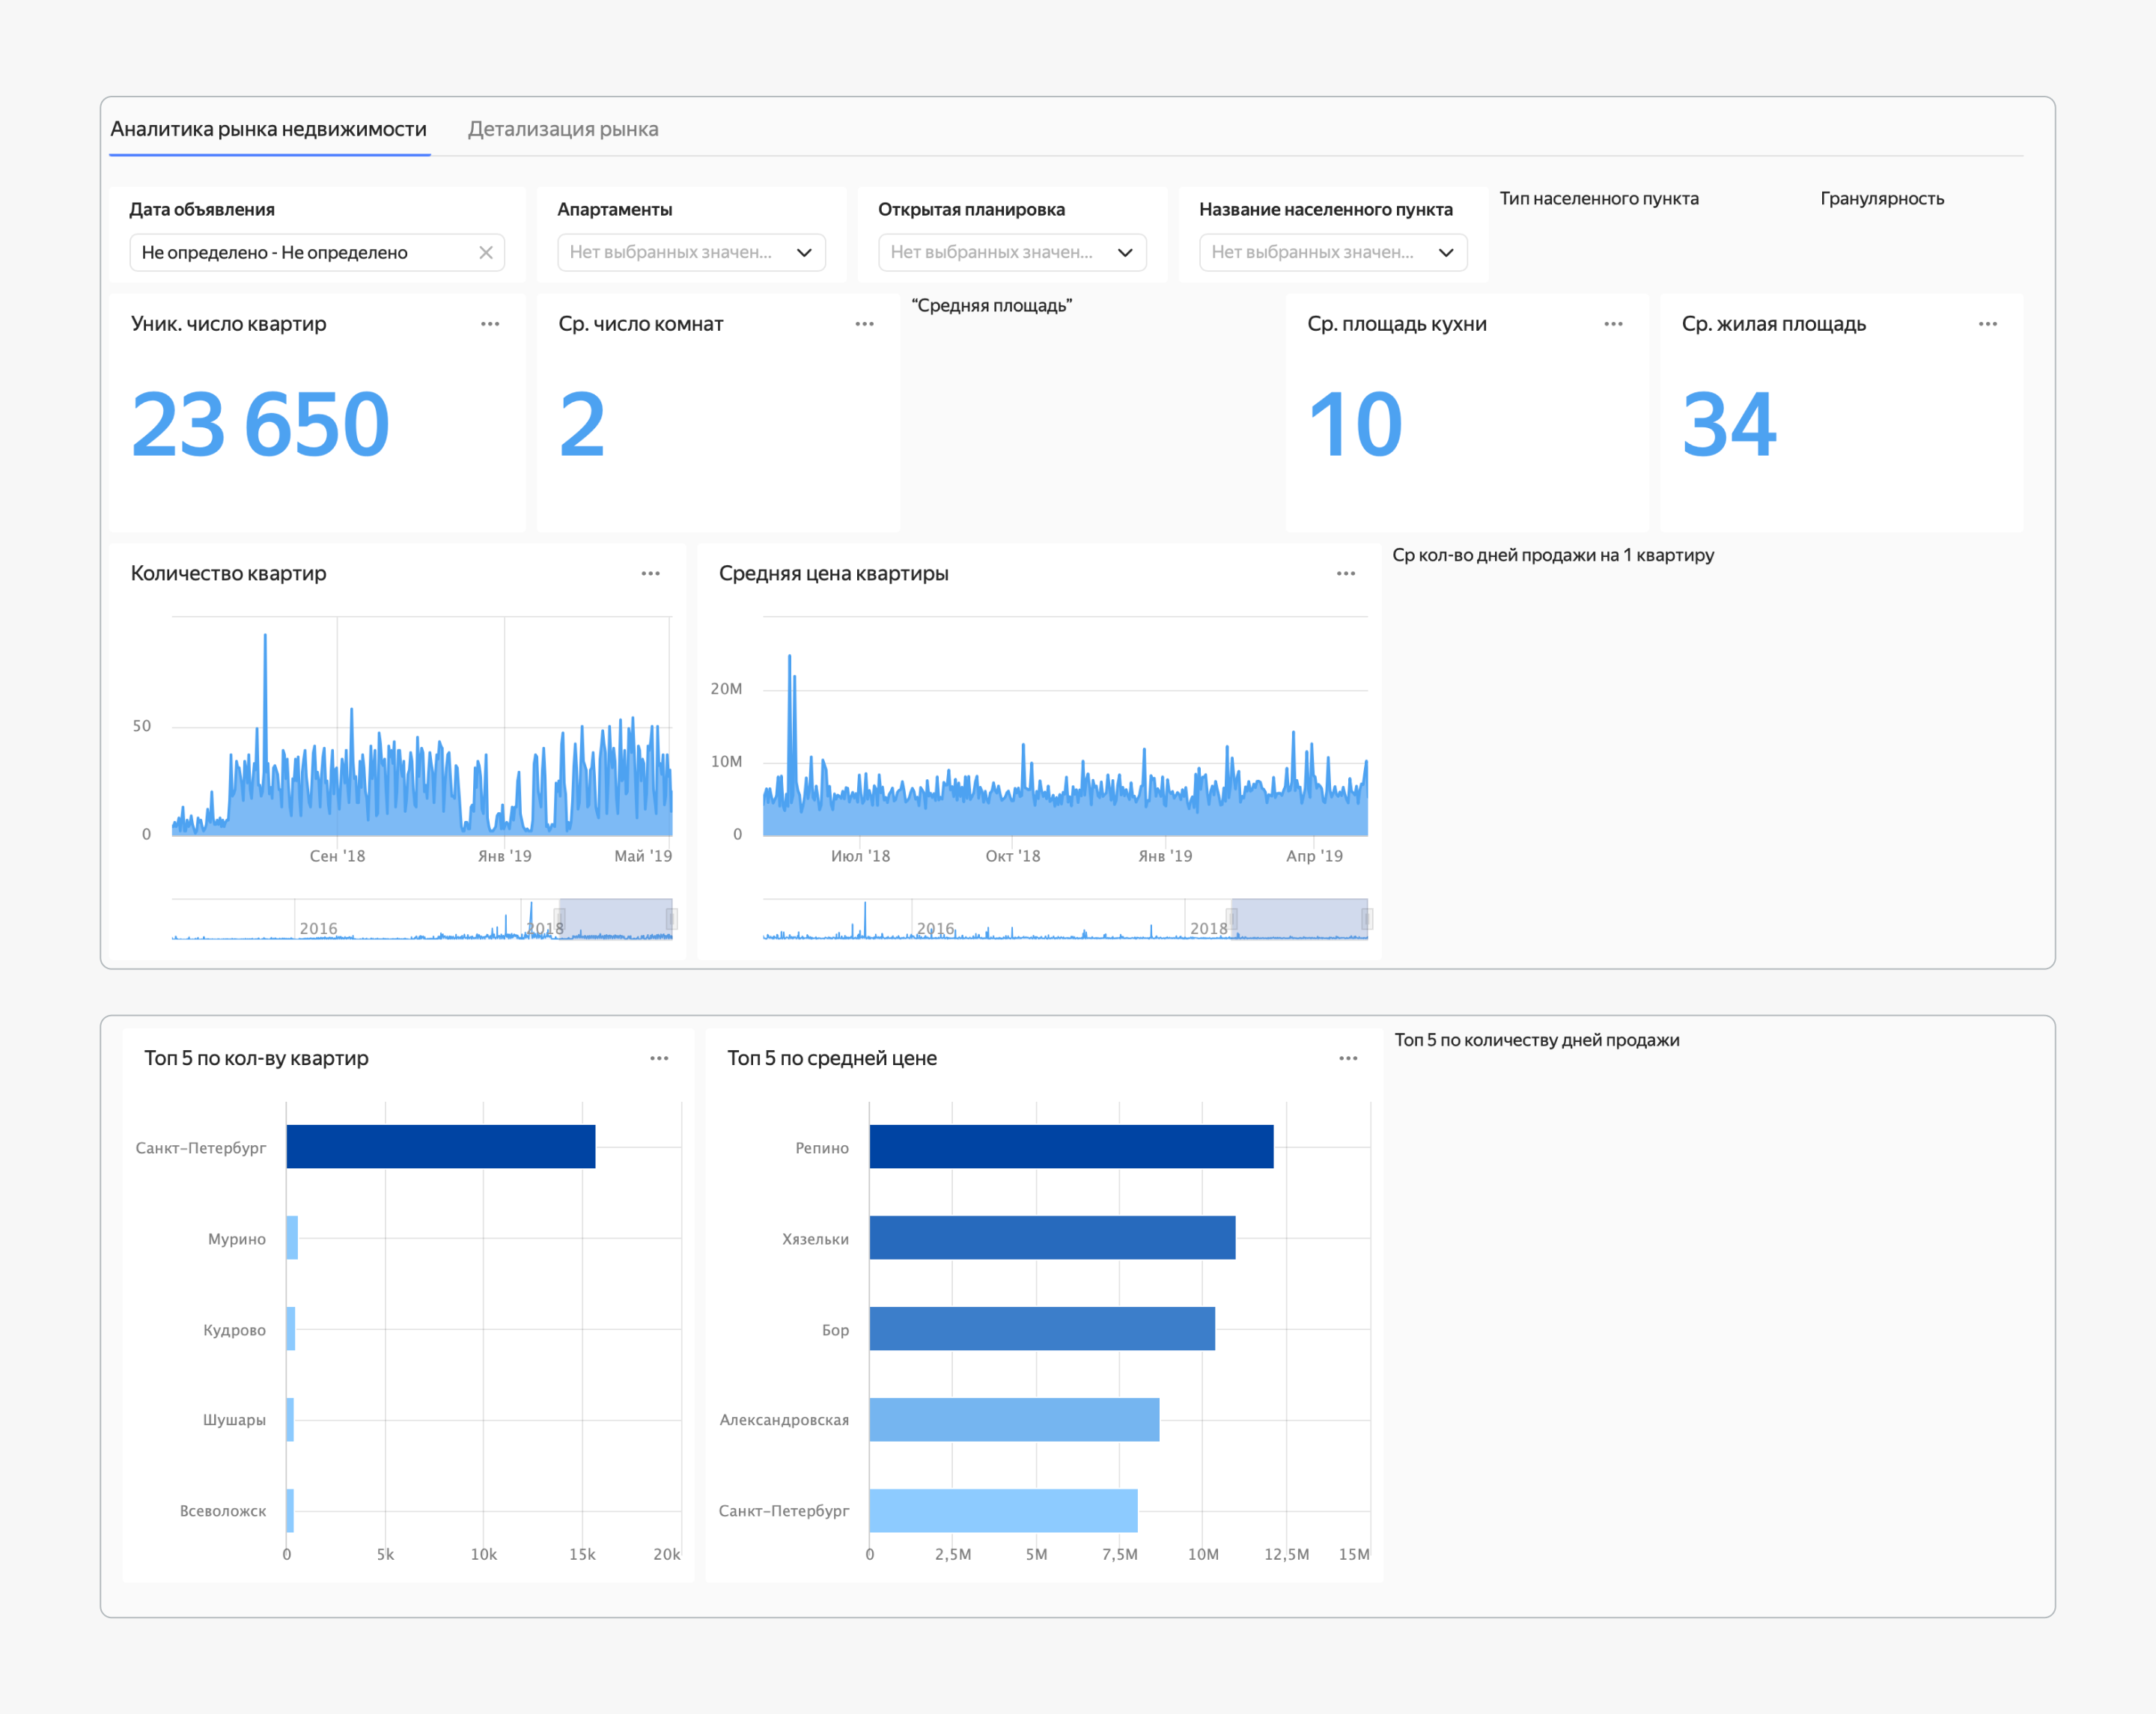

Задачи:
- Добавить фильтр по типам населённых пунктов. Этот фильтр позволит пользователям выбрать интересующие их типы населённых пунктов и сосредоточиться на интересующих их городах.
- Вывести показатель «Средняя площадь». Он даст представление о стандартных размерах квартир, пользующихся спросом на рынке.
- Отобразить среднее количество дней продажи на одну квартиру. Эта метрика покажет уровень спроса и предложения на рынке и поможет оценить, насколько быстро в среднем продаются квартиры. Метрика должна быть визуализирована так же, как и соседние две — «Количество квартир» и «Средняя цена квартиры».
- Создать чарт «Топ-5 по количеству дней продажи». Сотруднику агентства важно видеть населённые пункты, где квартиры продаются быстрее всего. Добавить цветовое выделение, которое проиллюстрирует разную скорость продаж. Использовать среднее значение по полю days_exposition и отобрать пять населённых пунктов с минимальными значениями.
- Добавить фильтр «Гранулярность» для детализации данных по дням, неделям, месяцам и годам. Так пользователи в деталях узнают о продажах квартир, ценах и сроках продажи — в зависимости от выбранного периода времени. Детализация данных по дням, неделям, месяцам и годам должна быть на таких визуализациях: «Количество квартир», «Средняя цена квартиры», «Среднее количество дней продажи одной квартиры».

Доработанная вкладка «Аналитика рынка недвижимости»:

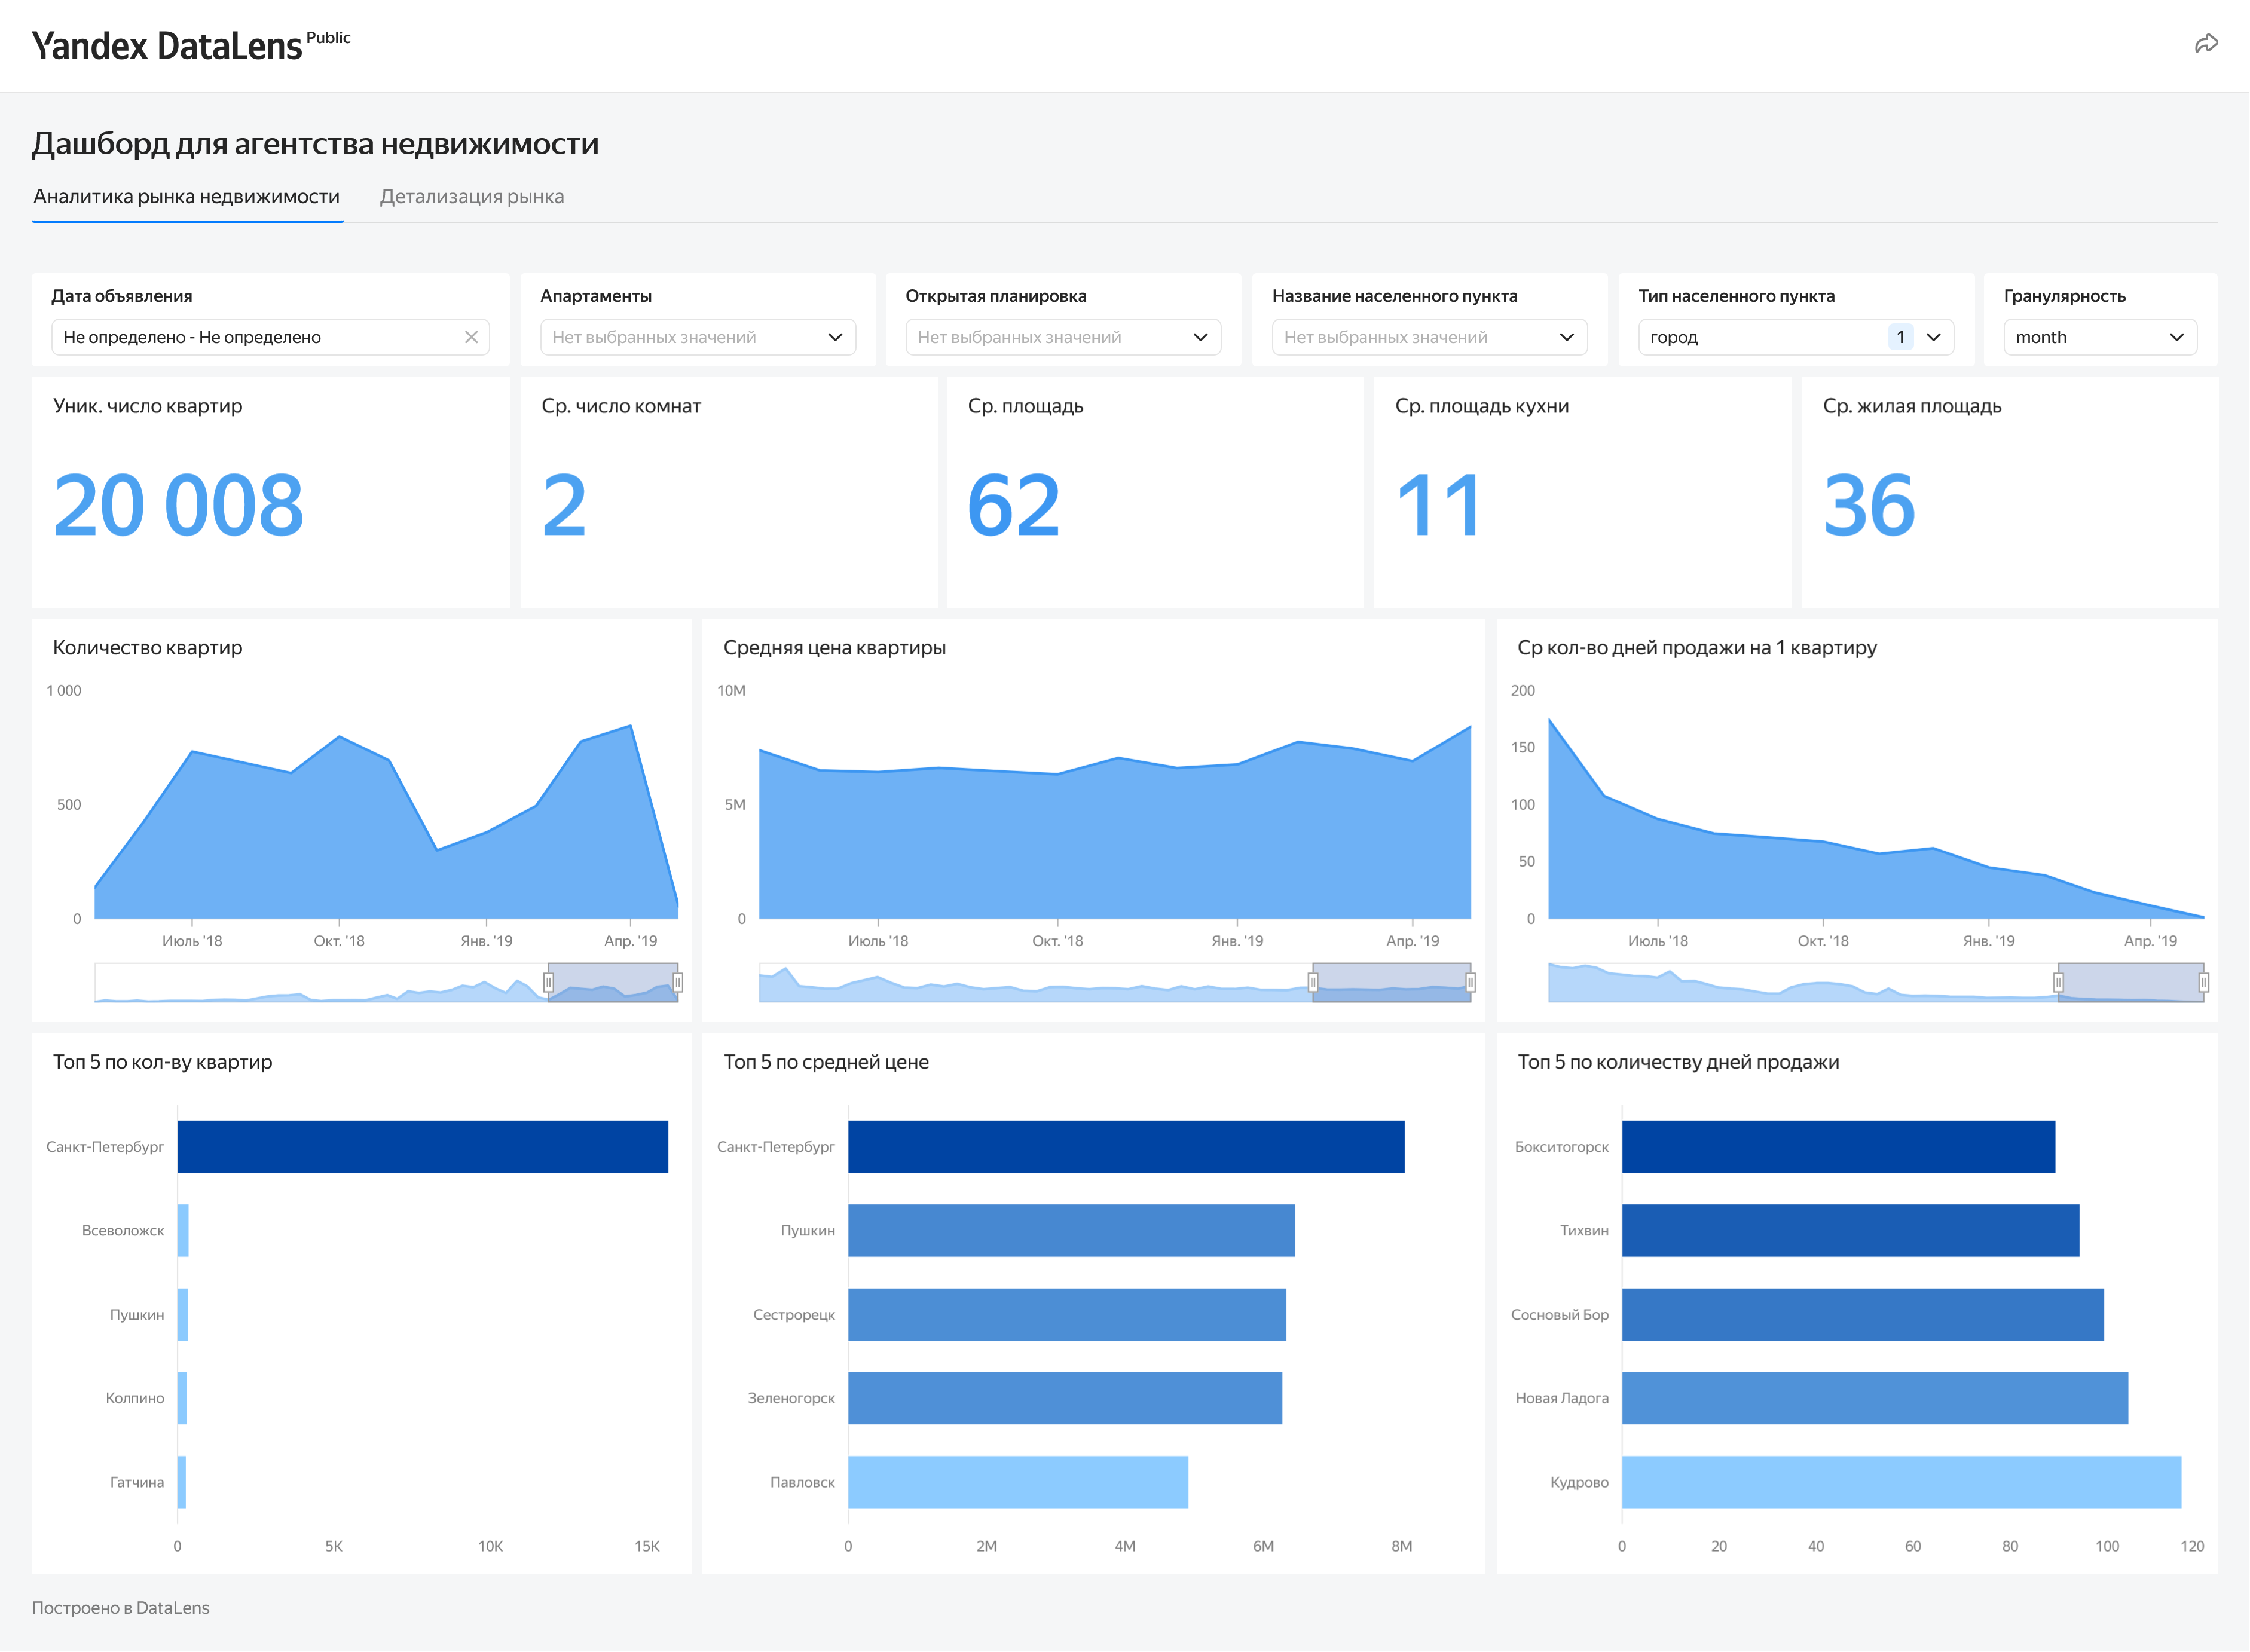

### 5.2. Вкладка «Детализация рынка»

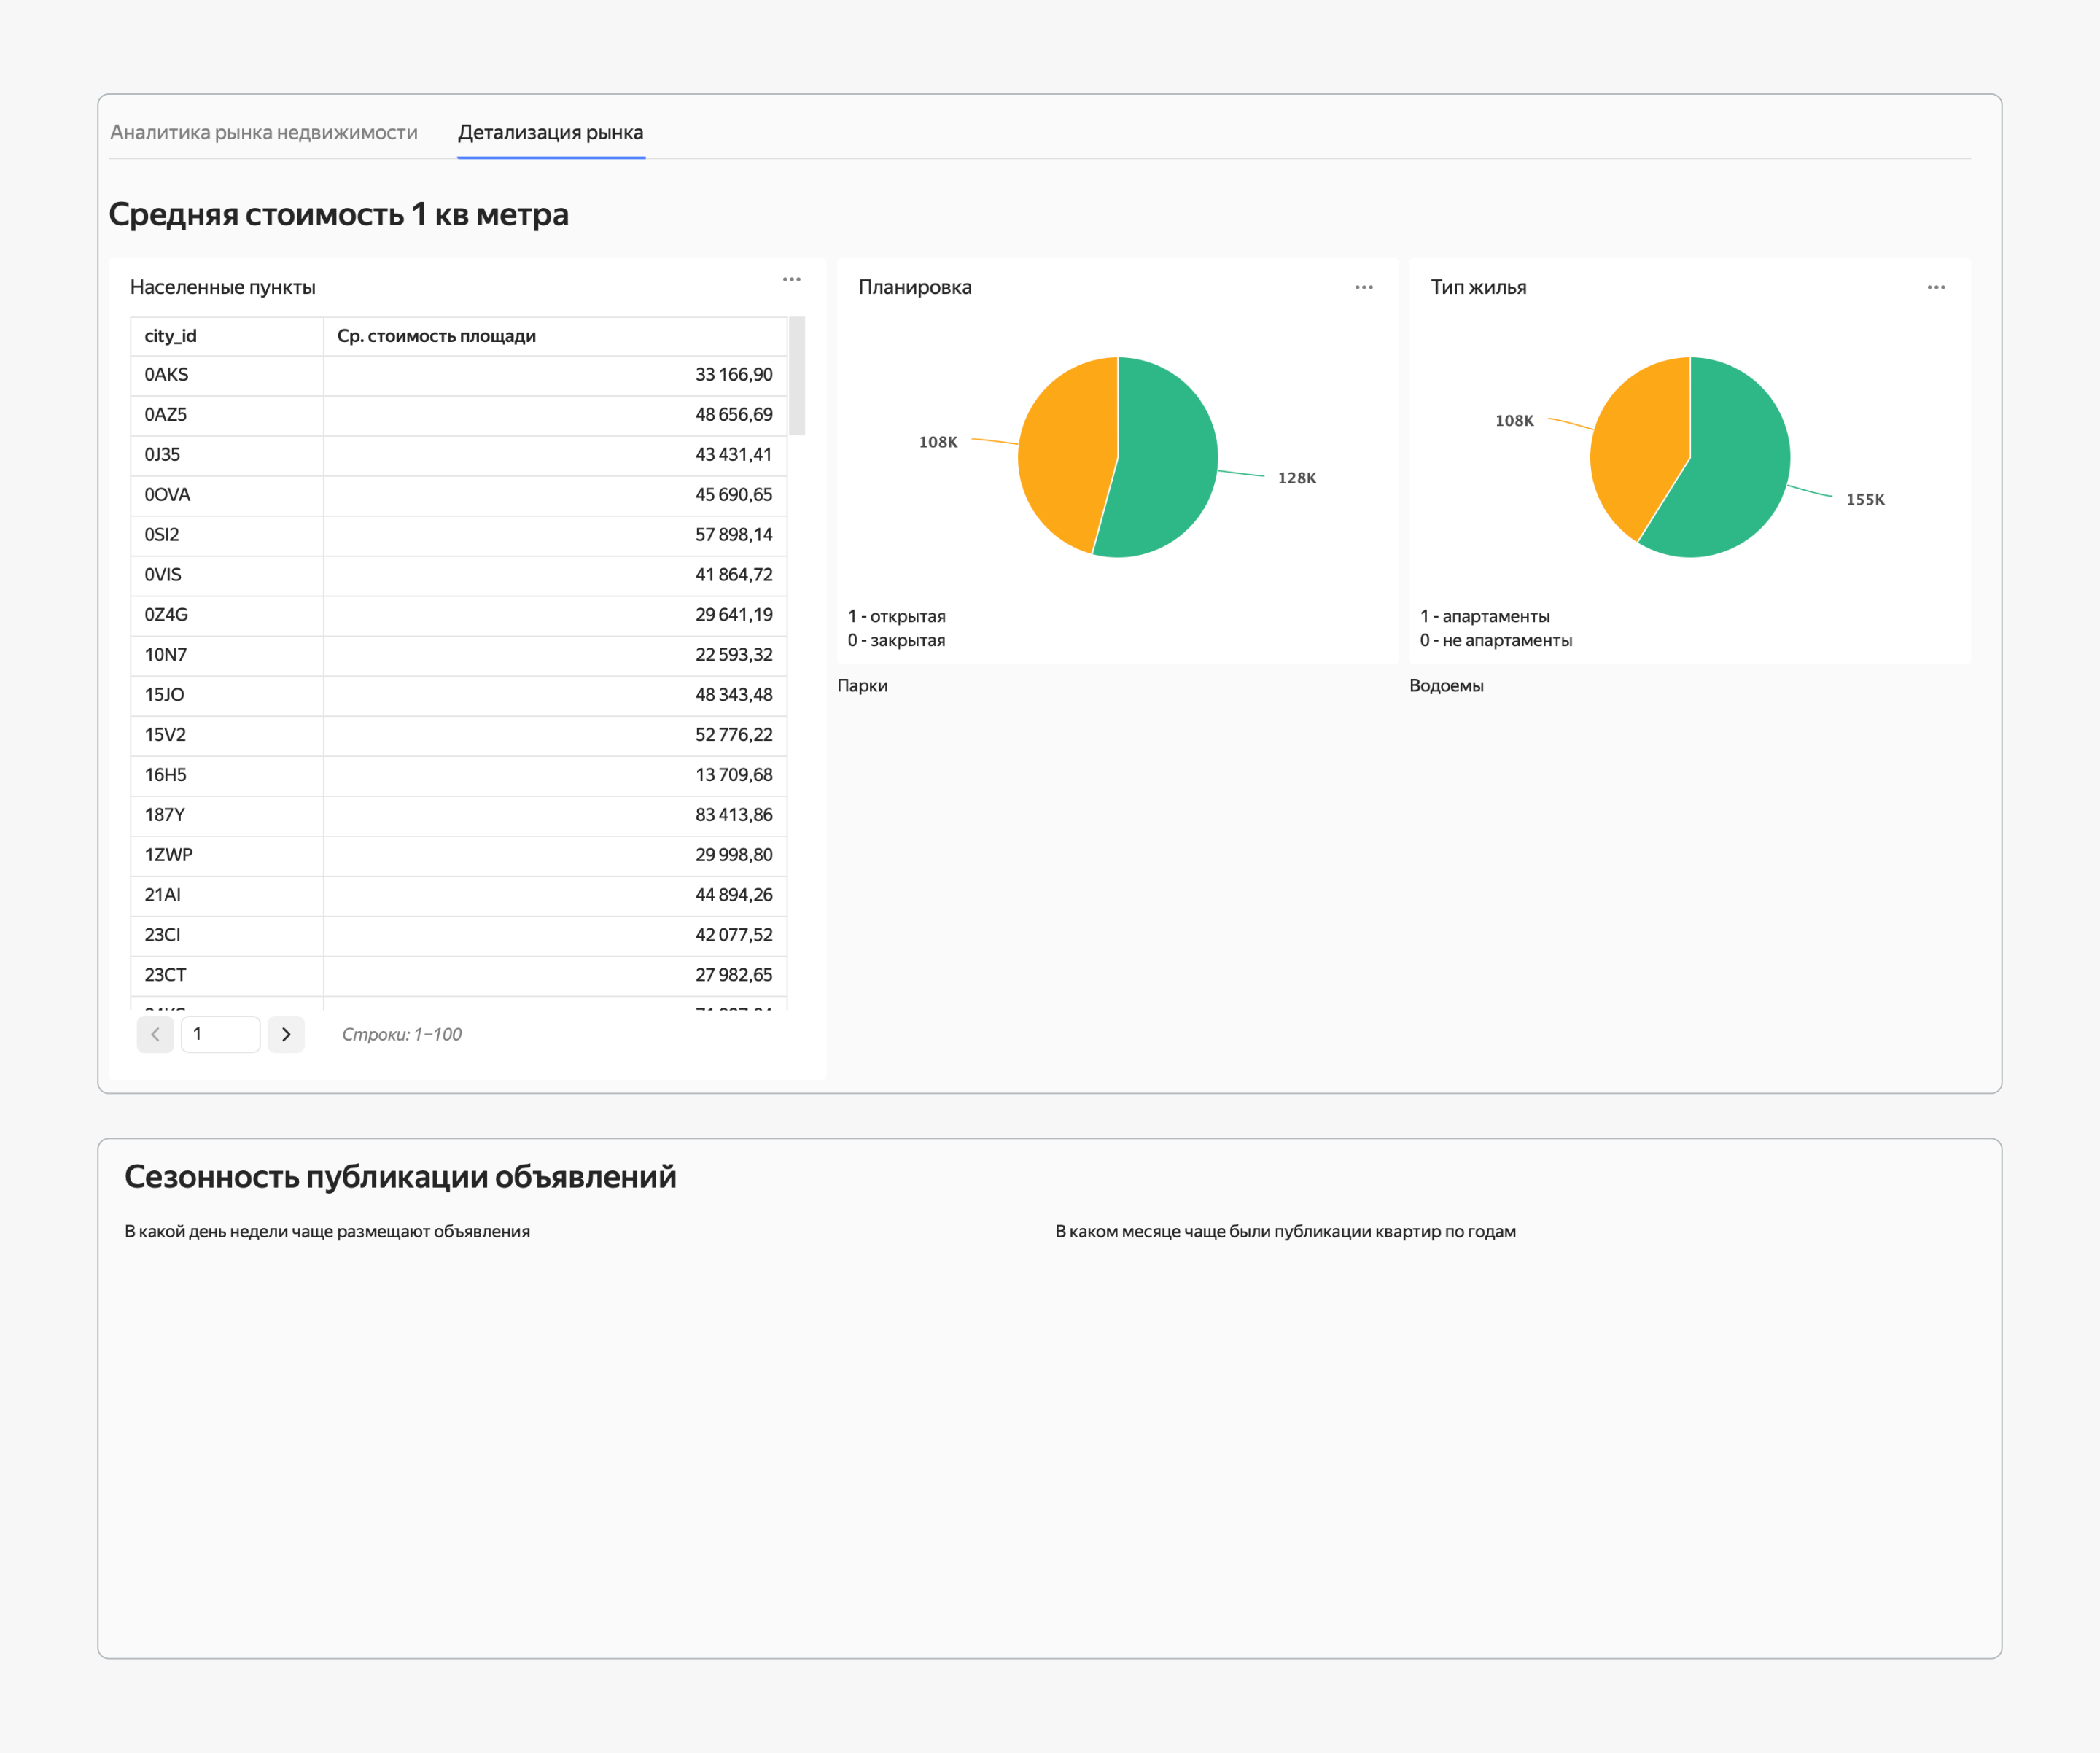

Задачи:
- В чарт по населённым пунктам добавить названия населённых пунктов и переименовать колонку с city_id в понятное название.
Ещё нужно отсортировать данные по средней стоимости площади: от большей к меньшей. Значения стоимости раскрасить в градиент: самые дорогие — красными, средние по цене — жёлтыми, самые дешёвые — зелёными.
- Сейчас средняя стоимость квадратного метра жилья в зависимости от планировки и типа жилья отображена в виде круговой диаграммы. Заменить тип графика на столбчатые диаграммы.
- Создать признаки, которые покажут, есть ли рядом водоём или парк, — они помогут увидеть, влияет ли наличие этих особенностей на стоимость квадратного метра жилья. Добаить их в виде столбчатых диаграмм по аналогии с обновлёнными визуализациями для планировки и типа жилья.
- Нужно выяснить, в какие дни недели пользователи чаще публикуют объявления о продаже квартир. Самый активный день (с наибольшим количеством публикаций) раскрасить зелёным цветом, наименее активный — красным, остальные дни — жёлтым.
- Важно узнать, как время года и год публикации влияют на количество размещённых объявлений. Для этого построить график, где каждая линия обозначит один год, а по горизонтали (ось X) будут отмечены месяцы. Этот график поможет увидеть, как меняется количество объявлений в разные месяцы разных лет и есть ли какие-то сезонные закономерности или «провалы» в данных.

Доработанная вкладка «Детализация рынка»:

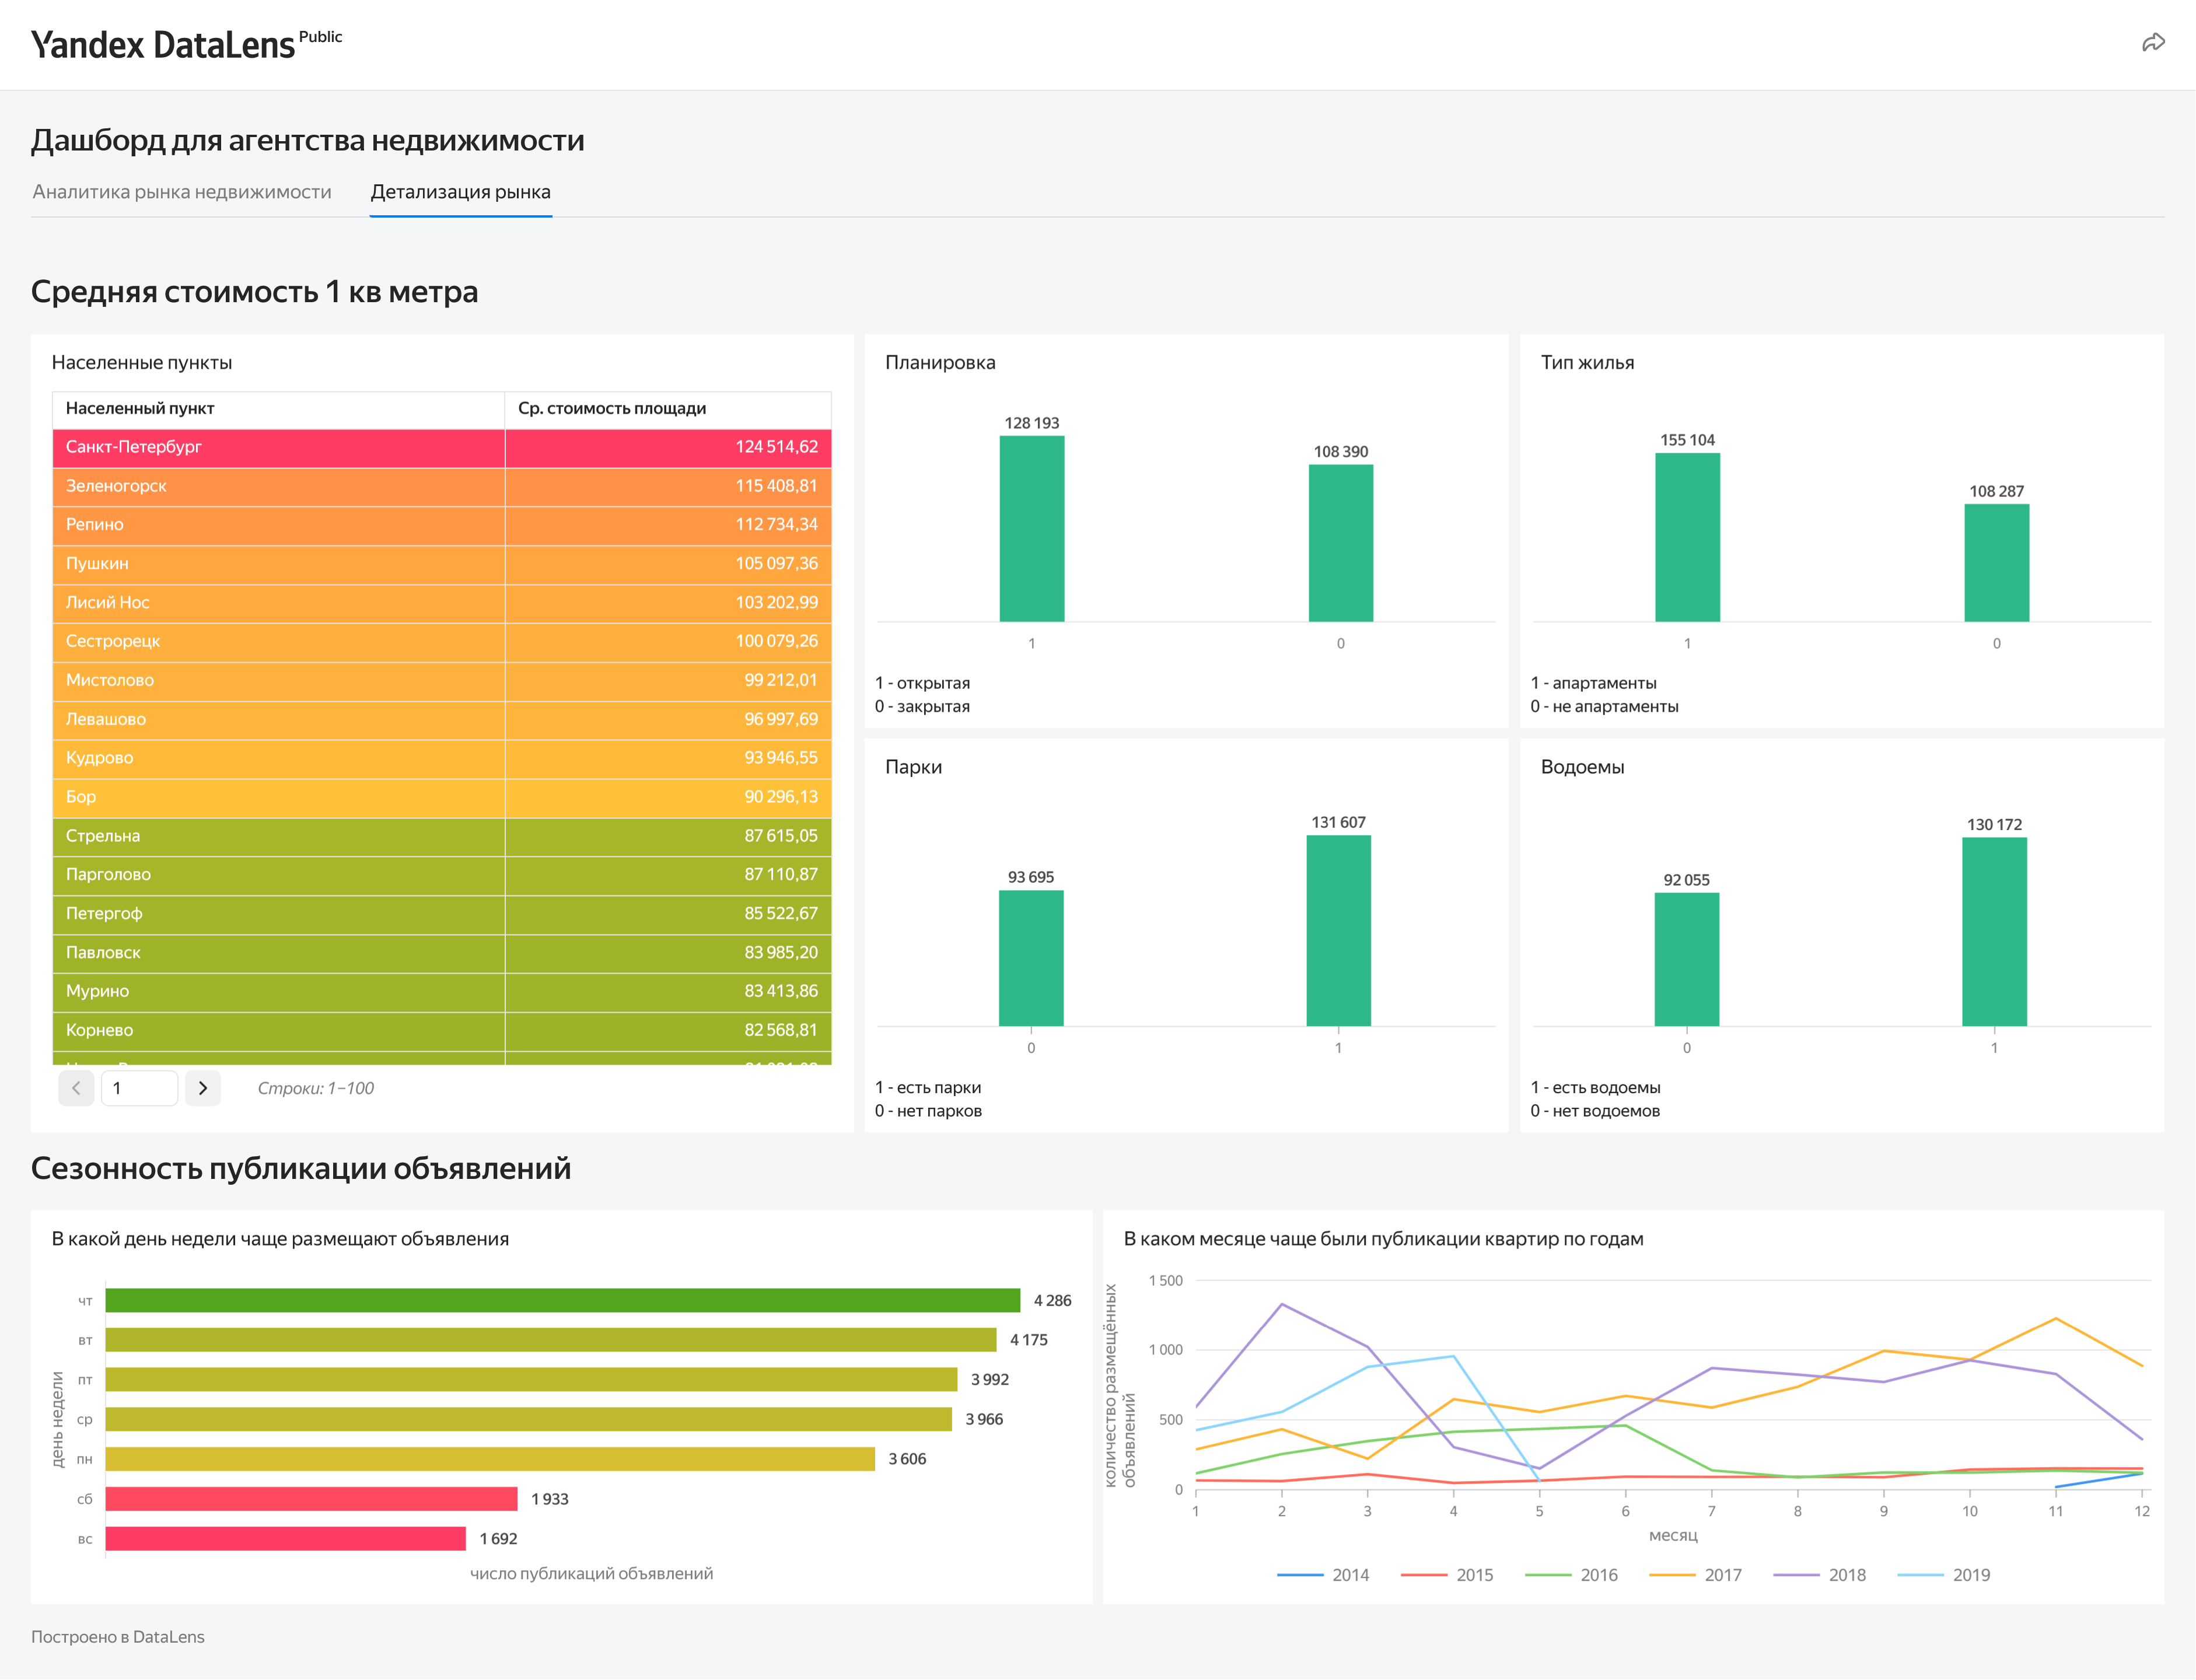

Доработанный дашборд доступен по ссылке [ссылке](https://datalens.yandex/dx04njqwknfsy)